In [41]:
"""
Summarize ML warm-start AL trajectories:
- Count iterations needed to reach the best candidate
- EXCLUDE warm-start points from the iteration count
- Compare LLM warm-start vs random warm-start
Grouped by: dataset, model, alpha, #warmstart points, seed, subset_key

Assumptions about trajectory CSVs:
- Produced by your script with columns including:
  ["Phase", "Stopping Reason", "Observed Target Value", "Index", ...]
- Phase values: "WarmStart" and "ActiveLearning"
- Files live under:
  al_trajectory_data_all/<dataset>/ML_warmstart_from_LLMsubsets/*.csv
  al_trajectory_data_all/<dataset>/ML_random_matched_to_LLMsubsets/*.csv
"""

import os
import re
import glob
import numpy as np
import pandas as pd

# -----------------------
# CONFIG
# -----------------------
OUT_BASE = "al_trajectory_data_all"
WARM_DIRNAME = "ML_warmstart_from_LLMsubsets"
RAND_DIRNAME = "ML_random_matched_to_LLMsubsets"

# if you want to restrict to certain datasets:
DATASETS = None  # e.g. ["Membrane_dataset", "Perovskite_dataset"] or None for all found

# minimization datasets in YOUR setup (Perovskite uses y_df = -Instability index)
MINIMIZE_DATASETS = {"Perovskite_dataset"}  # add more if needed

# -----------------------
# Helpers
# -----------------------
def parse_fname_metadata(fname: str):
    """
    Expected filename pattern from your code:
      {model}__{dataset}__a{alphaTag}__seed{seed}__{run_kind}__{subset_key}.csv
    where alphaTag like 0p1 for 0.1, or 1 for 1.0.
    """
    base = os.path.basename(fname)
    stem = base[:-4] if base.lower().endswith(".csv") else base
    parts = stem.split("__")
    if len(parts) < 6:
        return None

    model = parts[0]
    dataset = parts[1]

    # alpha tag: e.g. "a0p1" or "a1"
    a_tag = parts[2]
    if not a_tag.startswith("a"):
        return None
    alpha_str = a_tag[1:].replace("p", ".").replace("m", "-")
    try:
        alpha = float(alpha_str)
    except Exception:
        alpha = np.nan

    # seed: e.g. "seed42"
    seed_part = parts[3]
    m = re.search(r"seed(\d+)", seed_part, re.IGNORECASE)
    seed = int(m.group(1)) if m else None

    run_kind = parts[4]  # "warm" or "rand"
    subset_key = "__".join(parts[5:])  # may include extra "__" if any

    return dict(
        model=model,
        dataset=dataset,
        alpha=alpha,
        seed=seed,
        run_kind=run_kind,
        subset_key=subset_key,
        file=fname,
    )

def warmstart_count_from_df(df: pd.DataFrame) -> int:
    if "Phase" not in df.columns:
        return 0
    return int((df["Phase"] == "WarmStart").sum())

def activelearning_rows(df: pd.DataFrame) -> pd.DataFrame:
    if "Phase" in df.columns:
        return df[df["Phase"] == "ActiveLearning"].copy()
    # fallback: assume all are AL
    return df.copy()

def iterations_to_best_excluding_warmstart(df: pd.DataFrame, dataset: str):
    """
    Returns:
      - iters_to_best: number of AL selections until best candidate is first reached (1-based),
                       excluding warmstart points.
      - reached_best: bool
      - best_value_true: best achieved within the run (max or min depending on dataset)
      - best_value_global: global best within this run's recorded data? (same as above)
    Notes:
      - We interpret "best candidate reached" as hitting the best *observed* value in the run
        (AL phase only) OR if "Stopping Reason" includes "reached".
      - If you want "dataset-global optimum", this code infers from the run itself.
        If you stored "Max ... in Dataset" / "Min ... in Dataset" column, we use that too.
    """
    df_al = activelearning_rows(df)
    if df_al.empty:
        return dict(iters_to_best=np.nan, reached_best=False, best_value_run=np.nan, best_value_dataset=np.nan)

    y = pd.to_numeric(df_al["Observed Target Value"], errors="coerce").to_numpy()

    minimize = dataset in MINIMIZE_DATASETS

    # Best value within AL trajectory (run)
    if minimize:
        best_run = np.nanmin(y)
    else:
        best_run = np.nanmax(y)

    # Find first AL step that hits the best_run (tolerant to float jitter)
    # Use exact match when possible, else isclose.
    hit_mask = np.isclose(y, best_run, rtol=0, atol=1e-12) | (y == best_run)
    if hit_mask.any():
        first_hit_idx0 = int(np.argmax(hit_mask))  # first True
        iters_to_best = first_hit_idx0 + 1  # 1-based count of AL selections
        reached_best = True
    else:
        iters_to_best = np.nan
        reached_best = False

    # If your file includes dataset-best column, try to read it
    best_dataset = np.nan
    # columns like "Max Instability index in Dataset" or "Min Instability index in Dataset"
    for c in df.columns:
        if (" in Dataset" in c) and (("Max " in c) or ("Min " in c)):
            # take first non-null
            v = pd.to_numeric(df[c], errors="coerce").dropna()
            if len(v):
                best_dataset = float(v.iloc[0])
                break

    return dict(
        iters_to_best=iters_to_best,
        reached_best=reached_best,
        best_value_run=float(best_run),
        best_value_dataset=float(best_dataset) if not np.isnan(best_dataset) else np.nan,
    )

# -----------------------
# Load all warm/rand trajectory files
# -----------------------
warm_files = glob.glob(os.path.join(OUT_BASE, "*", WARM_DIRNAME, "*.csv"))
rand_files = glob.glob(os.path.join(OUT_BASE, "*", RAND_DIRNAME, "*.csv"))

all_files = warm_files + rand_files
meta_rows = []
for fp in all_files:
    m = parse_fname_metadata(fp)
    if m is None:
        continue
    if DATASETS is not None and m["dataset"] not in DATASETS:
        continue
    meta_rows.append(m)

if not meta_rows:
    raise RuntimeError("No trajectory files found (or filename parsing failed).")

meta_df = pd.DataFrame(meta_rows)

# -----------------------
# Compute summary per file
# -----------------------
summ_rows = []
for _, r in meta_df.iterrows():
    fp = r["file"]
    df = pd.read_csv(fp)

    m = warmstart_count_from_df(df)

    stats = iterations_to_best_excluding_warmstart(df, r["dataset"])
    summ_rows.append({
        "dataset": r["dataset"],
        "model": r["model"],
        "alpha": r["alpha"],
        "seed": r["seed"],
        "run_kind": r["run_kind"],  # warm or rand
        "subset_key": r["subset_key"],
        "warmstart_points": m,
        "iters_to_best_excl_warmstart": stats["iters_to_best"],
        "reached_best": stats["reached_best"],
        "best_value_run": stats["best_value_run"],
        "best_value_dataset_col": stats["best_value_dataset"],
        "file": fp,
    })

summary_df = pd.DataFrame(summ_rows)

# -----------------------
# Pair warm vs rand for same dataset/model/alpha/seed/subset_key/warmstart_points
# -----------------------
key_cols = ["dataset", "model", "alpha", "seed", "subset_key", "warmstart_points"]
warm_df = summary_df[summary_df["run_kind"] == "warm"].copy()
rand_df = summary_df[summary_df["run_kind"] == "rand"].copy()

paired = warm_df.merge(
    rand_df,
    on=key_cols,
    how="inner",
    suffixes=("_warm", "_rand"),
)

# -----------------------
# Aggregate: mean/median iterations to best over repeats (seeds/subsets)
# Group by dataset, model, alpha, warmstart_points
# -----------------------
group_cols = ["dataset", "model", "alpha", "warmstart_points"]

def agg_block(df, col):
    return pd.Series({
        "n": df[col].notna().sum(),
        "mean": float(np.nanmean(df[col])) if df[col].notna().any() else np.nan,
        "median": float(np.nanmedian(df[col])) if df[col].notna().any() else np.nan,
        "std": float(np.nanstd(df[col])) if df[col].notna().any() else np.nan,
    })

agg_rows = []
for g, sub in paired.groupby(group_cols):
    dset, model, alpha, m = g
    w = agg_block(sub, "iters_to_best_excl_warmstart_warm")
    r = agg_block(sub, "iters_to_best_excl_warmstart_rand")
    agg_rows.append({
        "dataset": dset,
        "model": model,
        "alpha": alpha,
        "warmstart_points": m,

        "warm_n": w["n"],
        "warm_mean_iters": w["mean"],
        "warm_median_iters": w["median"],
        "warm_std_iters": w["std"],

        "rand_n": r["n"],
        "rand_mean_iters": r["mean"],
        "rand_median_iters": r["median"],
        "rand_std_iters": r["std"],

        "delta_mean_warm_minus_rand": w["mean"] - r["mean"] if (not np.isnan(w["mean"]) and not np.isnan(r["mean"])) else np.nan,
        "delta_median_warm_minus_rand": w["median"] - r["median"] if (not np.isnan(w["median"]) and not np.isnan(r["median"])) else np.nan,
    })

agg_df = pd.DataFrame(agg_rows).sort_values(["dataset", "model", "alpha", "warmstart_points"])

# -----------------------
# Save outputs
# -----------------------
out_summary = os.path.join(OUT_BASE, "warmstart_vs_random__per_file_summary.csv")
out_paired  = os.path.join(OUT_BASE, "warmstart_vs_random__paired_runs.csv")
out_agg     = os.path.join(OUT_BASE, "warmstart_vs_random__aggregated.csv")

summary_df.to_csv(out_summary, index=False)
paired.to_csv(out_paired, index=False)
agg_df.to_csv(out_agg, index=False)

print(f"[OK] Per-file summary -> {out_summary}")
print(f"[OK] Paired warm vs rand -> {out_paired}")
print(f"[OK] Aggregated summary -> {out_agg}")

# Show a quick table in notebook
display_cols = [
    "dataset", "model", "alpha", "warmstart_points",
    "warm_mean_iters", "rand_mean_iters",
    "delta_mean_warm_minus_rand",
    "warm_median_iters", "rand_median_iters",
    "delta_median_warm_minus_rand",
    "warm_n", "rand_n"
]
print("\n=== Aggregated (mean/median iters to best, excluding warmstart) ===")
print(agg_df[display_cols].to_string(index=False))

[OK] Per-file summary -> al_trajectory_data_all\warmstart_vs_random__per_file_summary.csv
[OK] Paired warm vs rand -> al_trajectory_data_all\warmstart_vs_random__paired_runs.csv
[OK] Aggregated summary -> al_trajectory_data_all\warmstart_vs_random__aggregated.csv

=== Aggregated (mean/median iters to best, excluding warmstart) ===
                      dataset model  alpha  warmstart_points  warm_mean_iters  rand_mean_iters  delta_mean_warm_minus_rand  warm_median_iters  rand_median_iters  delta_median_warm_minus_rand  warm_n  rand_n
             Membrane_dataset   BNN    0.1                 5        38.000000        26.000000                   12.000000               38.0               26.0                          12.0     1.0     1.0
             Membrane_dataset   BNN    0.1                 6        19.500000        13.000000                    6.500000               19.5               13.0                           6.5     2.0     2.0
             Membrane_dataset   BNN    0.1    

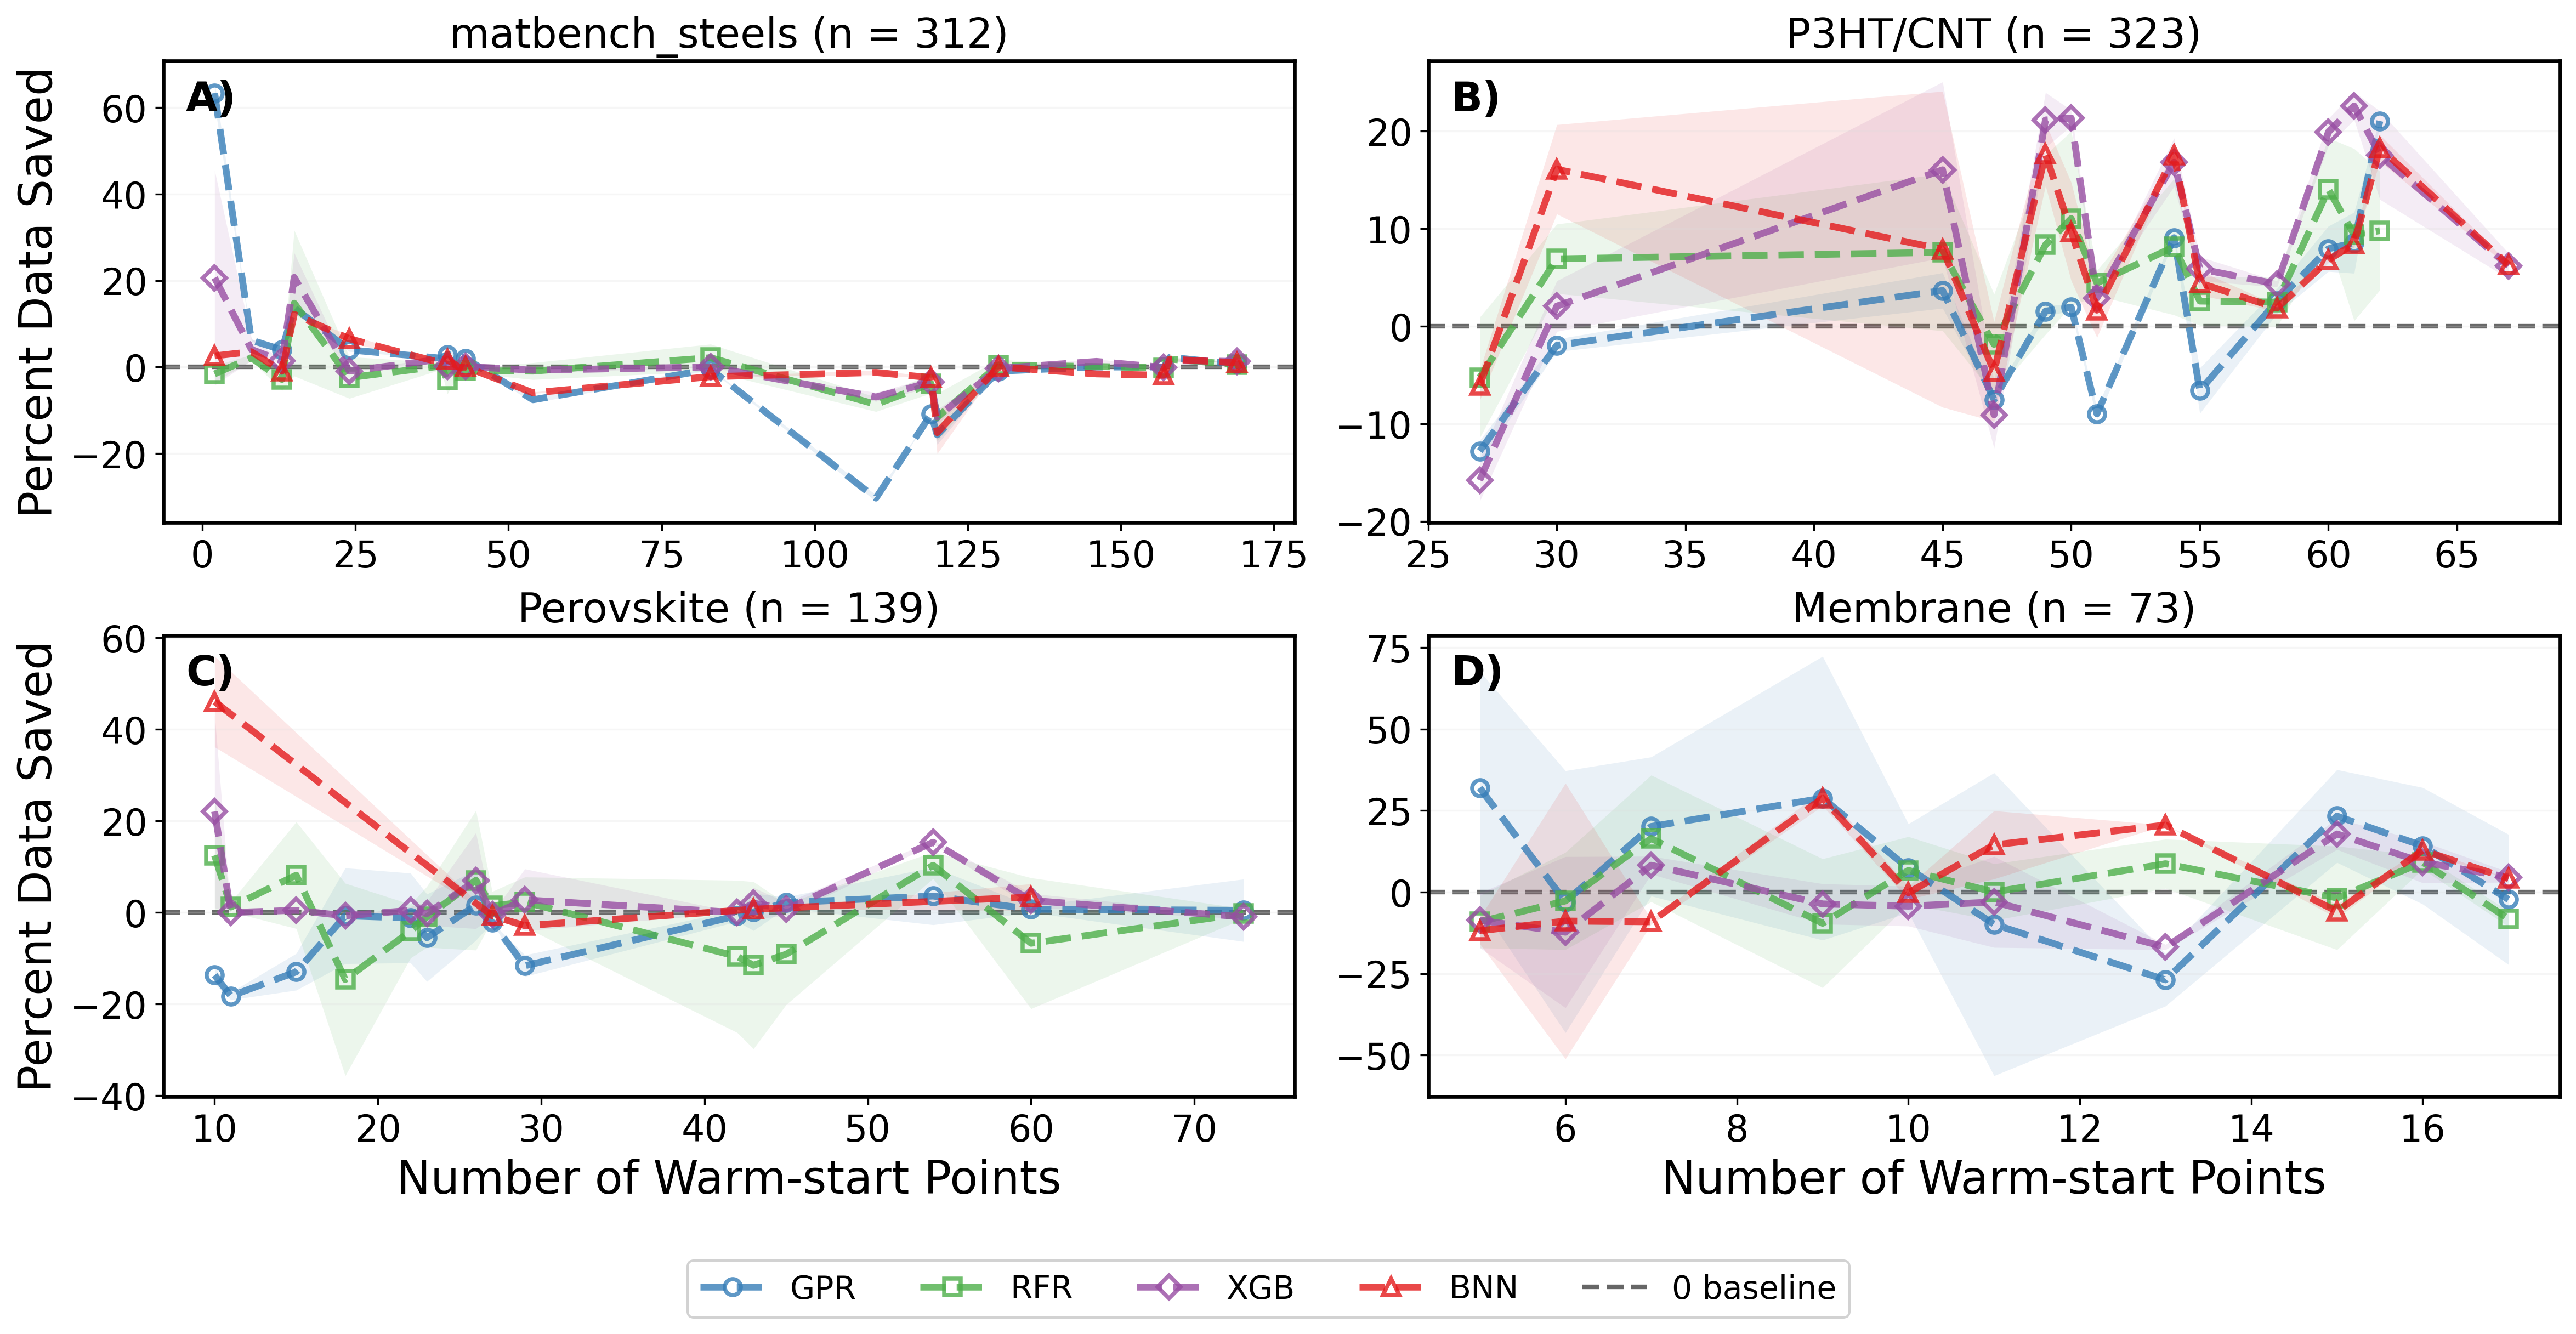

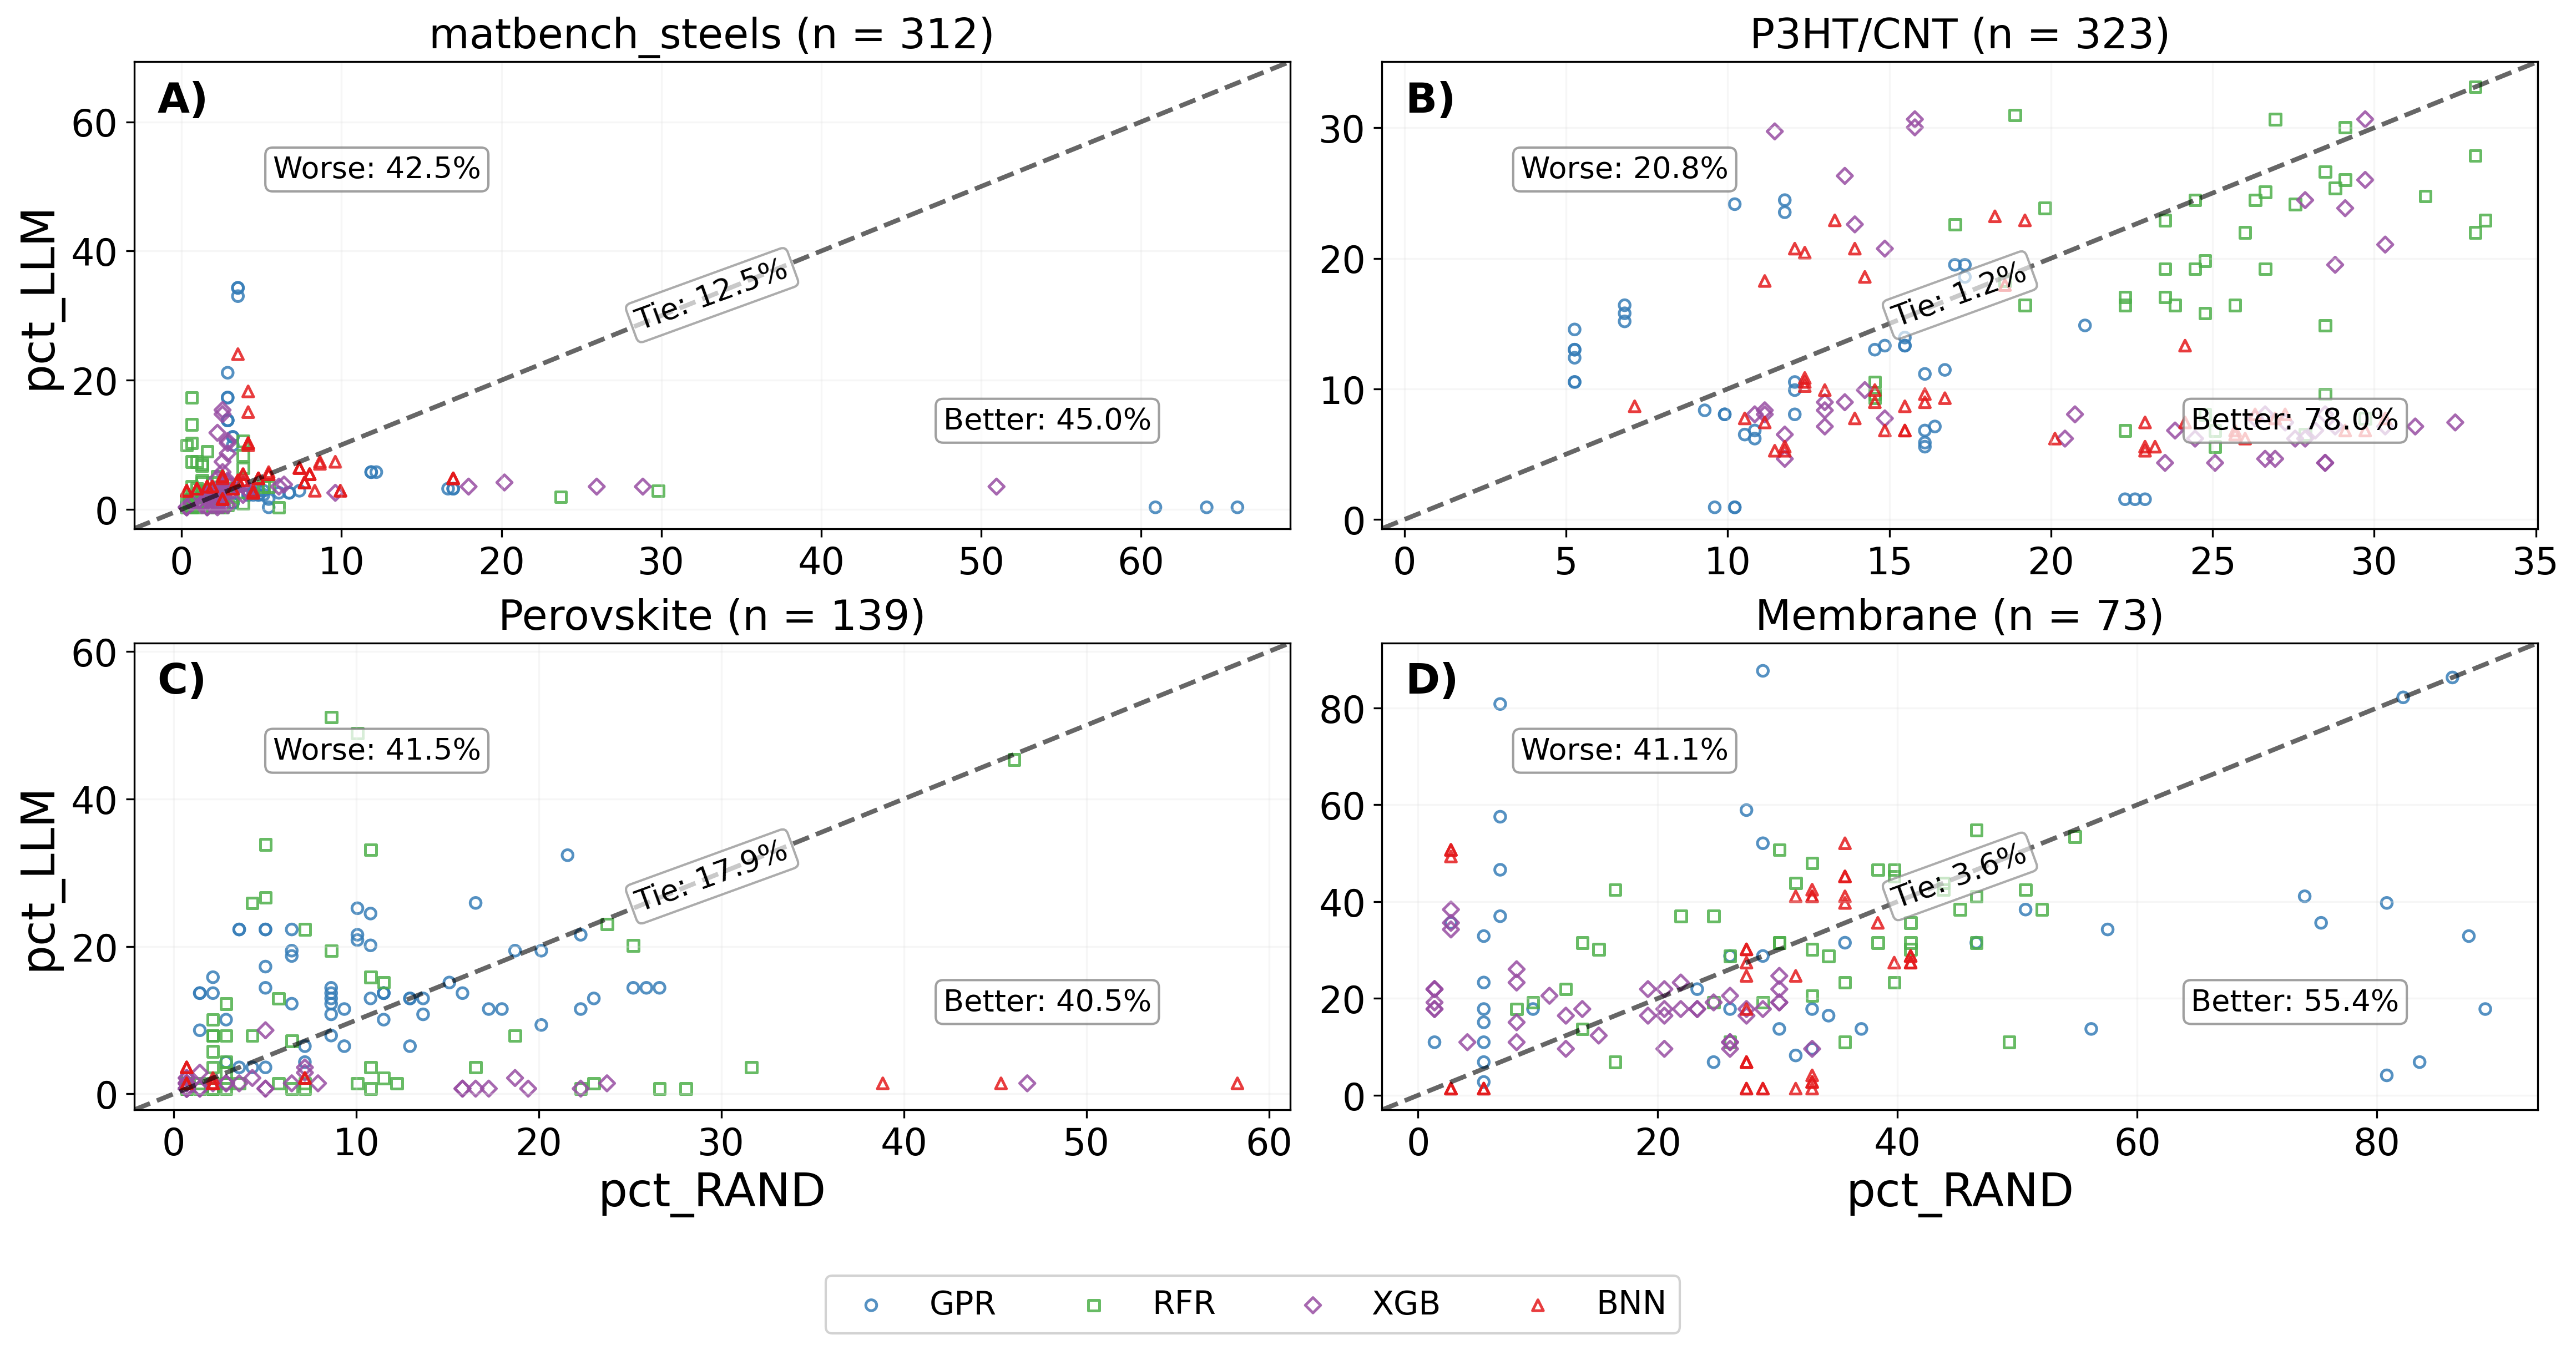

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from typing import Optional, Dict

# ----------------------------
# Config (match your style)
# ----------------------------
base_dir = "al_trajectory_data_all"
paired_csv = os.path.join(base_dir, "warmstart_vs_random__paired_runs.csv")

datasets = [
    "matbench_steels (composition)",
    "P3HT_dataset",
    "Perovskite_dataset",
    "Membrane_dataset",
]
dataset_display_name = {
    "matbench_steels (composition)": "matbench_steels",
    "P3HT_dataset": "P3HT/CNT",
    "Perovskite_dataset": "Perovskite",
    "Membrane_dataset": "Membrane",
}

dataset_sizes = {
    "matbench_steels (composition)": 312,
    "P3HT_dataset": 323,     # <- update if needed
    "Perovskite_dataset": 139,
    "Membrane_dataset": 73,
}

ml_models = ["GPR", "RFR", "XGB", "BNN"]

plt.rcParams.update({
    "figure.titlesize": 24,
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "legend.title_fontsize": 16
})

_set1 = sns.color_palette("Set1", 4)
ml_colors = {
    "BNN": _set1[0],
    "GPR": _set1[1],
    "RFR": _set1[2],
    "XGB": _set1[3],
}
ML_MARKERS = {"GPR": "o", "RFR": "s", "XGB": "D", "BNN": "^"}

alpha_band = 0.10
lw_line = 3.0
line_alpha = 0.80
grid_color = "#dddddd"

# ----------------------------
# Load + compute base quantities
# ----------------------------
if not os.path.exists(paired_csv):
    raise FileNotFoundError(f"Missing: {paired_csv}\nPlease generate the paired summary first.")

df = pd.read_csv(paired_csv)

required = {
    "dataset", "model", "alpha", "seed", "warmstart_points",
    "iters_to_best_excl_warmstart_warm",
    "iters_to_best_excl_warmstart_rand",
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"paired summary CSV missing columns: {missing}")

def pct_used(iters: pd.Series, dataset: pd.Series) -> np.ndarray:
    Ns = dataset.map(dataset_sizes).astype(float).to_numpy()
    return 100.0 * (iters.to_numpy(dtype=float) / Ns)

df["pct_llm"]  = pct_used(df["iters_to_best_excl_warmstart_warm"], df["dataset"])
df["pct_rand"] = pct_used(df["iters_to_best_excl_warmstart_rand"], df["dataset"])

# safety
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["pct_llm", "pct_rand"])
eps = 1e-12
df.loc[df["pct_rand"] <= eps, "pct_rand"] = np.nan
df = df.dropna(subset=["pct_rand"])

# ----------------------------
# Metric we keep: absolute savings (percentage points)
# ----------------------------
# positive = better (LLM uses fewer AL iterations as % of dataset)
df["savings_pp"] = df["pct_rand"] - df["pct_llm"]

# ----------------------------
# Aggregator for savings vs warmstart_points
# ----------------------------
def agg_mean_sd(df_in: pd.DataFrame, value_col: str) -> pd.DataFrame:
    agg = (
        df_in.groupby(["dataset", "model", "warmstart_points"], as_index=False)
            .agg(mean=(value_col, "mean"),
                 sd=(value_col, "std"),
                 n=(value_col, "count"))
    )
    agg["sd"] = agg["sd"].fillna(0.0)
    return agg

# ----------------------------
# 2×2 line plot helper (ONLY two y-axis labels: panels A and C)
# ----------------------------
def plot_2x2_savings(
    agg: pd.DataFrame,
    title: str,
    ylabel_left: str,
    baseline: float = 0.0,
):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), dpi=300)
    axes = np.ravel(axes)

    legend_handles, legend_labels = [], []
    panel_labels = ["A)", "B)", "C)", "D)"]

    for i, ds in enumerate(datasets):
        ax = axes[i]
        sub = agg[agg["dataset"] == ds].copy()

        for model in ml_models:
            s = sub[sub["model"] == model].sort_values("warmstart_points")
            if s.empty:
                continue

            x = s["warmstart_points"].to_numpy(dtype=float)
            y = s["mean"].to_numpy(dtype=float)
            sd = s["sd"].to_numpy(dtype=float)

            c = ml_colors[model]
            marker = ML_MARKERS.get(model, "o")

            if len(x) > 1:
                ax.fill_between(x, y - sd, y + sd, color=c, alpha=alpha_band, linewidth=0, zorder=1)

            markevery = max(1, len(x) // 10)
            line, = ax.plot(
                x, y,
                color=c,
                linewidth=lw_line,
                alpha=line_alpha,
                linestyle="--",
                marker=marker,
                markevery=markevery,
                markersize=7,
                markerfacecolor="none",
                markeredgecolor=c,
                markeredgewidth=1.8,
                zorder=2,
                label=model
            )

            if model not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(model)

        ax.axhline(baseline, color="black", linestyle="--", linewidth=2.0, alpha=0.6, zorder=0)

        disp = dataset_display_name.get(ds, ds)
        n_total = dataset_sizes.get(ds, None)
        ax.set_title(f"{disp} (n = {n_total})" if n_total is not None else disp)

        # Only panels A (i=0) and C (i=2) get y-label
        if i in (0, 2):
            ax.set_ylabel(ylabel_left)
        else:
            ax.set_ylabel("")

        # Only bottom row gets x-label
        if i >= 2:
            ax.set_xlabel("Number of Warm-start Points")
        else:
            ax.set_xlabel("")

        ax.grid(True, axis="y", alpha=0.25, color=grid_color)
        for sp in ("top", "right", "bottom", "left"):
            ax.spines[sp].set_visible(True)
            ax.spines[sp].set_linewidth(1.6)

        ax.text(
            0.02, 0.96, panel_labels[i],
            transform=ax.transAxes,
            fontsize=plt.rcParams["axes.titlesize"],
            fontweight="bold",
            va="top", ha="left",
        )

    # Hide any unused axes
    for j in range(len(datasets), len(axes)):
        axes[j].set_visible(False)

    # Legend
    label_to_handle = {lab: h for h, lab in zip(legend_handles, legend_labels)}
    baseline_proxy = Line2D([0, 1], [0, 0], color="black", linestyle="--",
                            linewidth=2.0, alpha=0.6, label="0 baseline")
    label_to_handle["0 baseline"] = baseline_proxy

    legend_order = ["GPR", "RFR", "XGB", "BNN", "0 baseline"]
    ordered_labels = [lab for lab in legend_order if lab in label_to_handle]
    ordered_handles = [label_to_handle[lab] for lab in ordered_labels]

    fig.legend(
        ordered_handles, ordered_labels,
        loc="lower center", bbox_to_anchor=(0.5, -0.02),
        ncol=len(ordered_labels), frameon=True, framealpha=0.35,
        fancybox=True, edgecolor="gray"
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.16, left=0.08)
    plt.show()

# ----------------------------
# Plot 1: Savings vs warmstart_points
# ----------------------------
agg_sav = agg_mean_sd(df, "savings_pp")
plot_2x2_savings(
    agg_sav,
    title="LLM vs Random: Absolute savings in dataset used (pct_RAND − pct_LLM)",
    ylabel_left="Percent Data Saved",
    baseline=0.0
)

# ----------------------------
# Plot 2: Paired scatter with diagonal + % better/tie/worse annotations (positioned like you want)
# ONLY two y-axis labels: panels A and C
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 8), dpi=300)
axes = np.ravel(axes)
panel_labels = ["A)", "B)", "C)", "D)"]

# tie tolerance in percentage points on the pct scale
TIE_TOL = 1e-6  # treat |pct_llm - pct_rand| <= TIE_TOL as "tie"

for i, ds in enumerate(datasets):
    ax = axes[i]
    sub = df[df["dataset"] == ds].copy()

    # --- scatter by model ---
    for model in ml_models:
        s = sub[sub["model"] == model].copy()
        if s.empty:
            continue
        ax.scatter(
            s["pct_rand"], s["pct_llm"],
            s=22,
            marker=ML_MARKERS.get(model, "o"),
            facecolors="none",
            edgecolors=ml_colors[model],
            linewidths=1.2,
            alpha=0.85,
            label=model
        )

    # --- diagonal y=x ---
    all_vals = np.concatenate([sub["pct_rand"].to_numpy(), sub["pct_llm"].to_numpy()])
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    pad = 0.05 * (vmax - vmin + 1e-12)
    lo, hi = vmin - pad, vmax + pad
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=2.0, alpha=0.6)

    # --- percent better/tie/worse (overall, across models) ---
    pr = sub["pct_rand"].to_numpy(dtype=float)
    pl = sub["pct_llm"].to_numpy(dtype=float)
    ok = np.isfinite(pr) & np.isfinite(pl)
    pr, pl = pr[ok], pl[ok]

    n = pr.size
    if n > 0:
        diff = pl - pr  # <0 better (below), >0 worse (above)
        n_tie = int(np.sum(np.abs(diff) <= TIE_TOL))
        n_better = int(np.sum(diff < -TIE_TOL))
        n_worse = int(np.sum(diff >  TIE_TOL))

        p_better = 100.0 * n_better / n
        p_tie    = 100.0 * n_tie    / n
        p_worse  = 100.0 * n_worse  / n
    else:
        p_better = p_tie = p_worse = np.nan

    # ---- annotations positioned like your example ----
    # Better: lower-right-ish
    ax.text(
        0.7, 0.2,
        f"Better: {p_better:.1f}%",
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=13,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.75)
    )
    # Worse: upper-left-ish
    ax.text(
        0.3, 0.8,
        f"Worse: {p_worse:.1f}%",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=13,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray", alpha=0.75)
    )

    # Tie: along the diagonal (center-ish), rotated to match diagonal
    mid = 0.5 * (lo + hi)
    ax.text(
        mid, mid,
        f"Tie: {p_tie:.1f}%",
        rotation=20,
        rotation_mode="anchor",
        ha="center", va="center",
        fontsize=13,
        bbox=dict(boxstyle="round,pad=0.20", facecolor="white", edgecolor="gray", alpha=0.65)
    )

    # --- titles/labels ---
    disp = dataset_display_name.get(ds, ds)
    n_total = dataset_sizes.get(ds, None)
    ax.set_title(f"{disp} (n = {n_total})" if n_total is not None else disp)

    if i in (0, 2):
        ax.set_ylabel("pct_LLM")
    else:
        ax.set_ylabel("")

    if i >= 2:
        ax.set_xlabel("pct_RAND")
    else:
        ax.set_xlabel("")

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(True, alpha=0.25, color=grid_color)

    ax.text(
        0.02, 0.96, panel_labels[i],
        transform=ax.transAxes,
        fontsize=plt.rcParams["axes.titlesize"],
        fontweight="bold",
        va="top", ha="left"
    )

# Hide any unused axes
for j in range(len(datasets), len(axes)):
    axes[j].set_visible(False)

# Legend (models only)
handles, labels = axes[0].get_legend_handles_labels()
label_to_handle = {lab: h for h, lab in zip(handles, labels)}
legend_order = ["GPR", "RFR", "XGB", "BNN"]
ordered_labels = [lab for lab in legend_order if lab in label_to_handle]
ordered_handles = [label_to_handle[lab] for lab in ordered_labels]

fig.legend(
    ordered_handles, ordered_labels,
    loc="lower center", bbox_to_anchor=(0.5, -0.02),
    ncol=len(ordered_labels), frameon=True, framealpha=0.35,
    fancybox=True, edgecolor="gray"
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.16, left=0.08)
plt.show()